<center><h1>Last_First_HW1 - Iris Xia</h1></center>
<br>
<center><font size="4">Vertebral Column Data</font></center>

### (a) Download Data

Package imports

In [37]:
import pandas as pd
import numpy as np

Get the Vertebral Column Data Set

In [38]:
column_names = [
    "pelvic_incidence",
    "pelvic_tilt",
    "lumbar_lordosis_angle",
    "sacral_slope",
    "pelvic_radius",
    "grade_of_spondylolisthesis",
    "class"
]

df = pd.read_csv('/Users/xiada/Downloads/DSCI 552/HW1/column_2C.dat', sep=r"\s+", names=column_names)
df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_of_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,AB
1,39.06,10.06,25.02,29.00,114.41,4.56,AB
2,68.83,22.22,50.09,46.61,105.99,-3.53,AB
3,69.30,24.65,44.31,44.64,101.87,11.21,AB
4,49.71,9.65,28.32,40.06,108.17,7.92,AB


### (b) Pre-Processing and Exploratory Data Analysis

#### i. Scatterplots

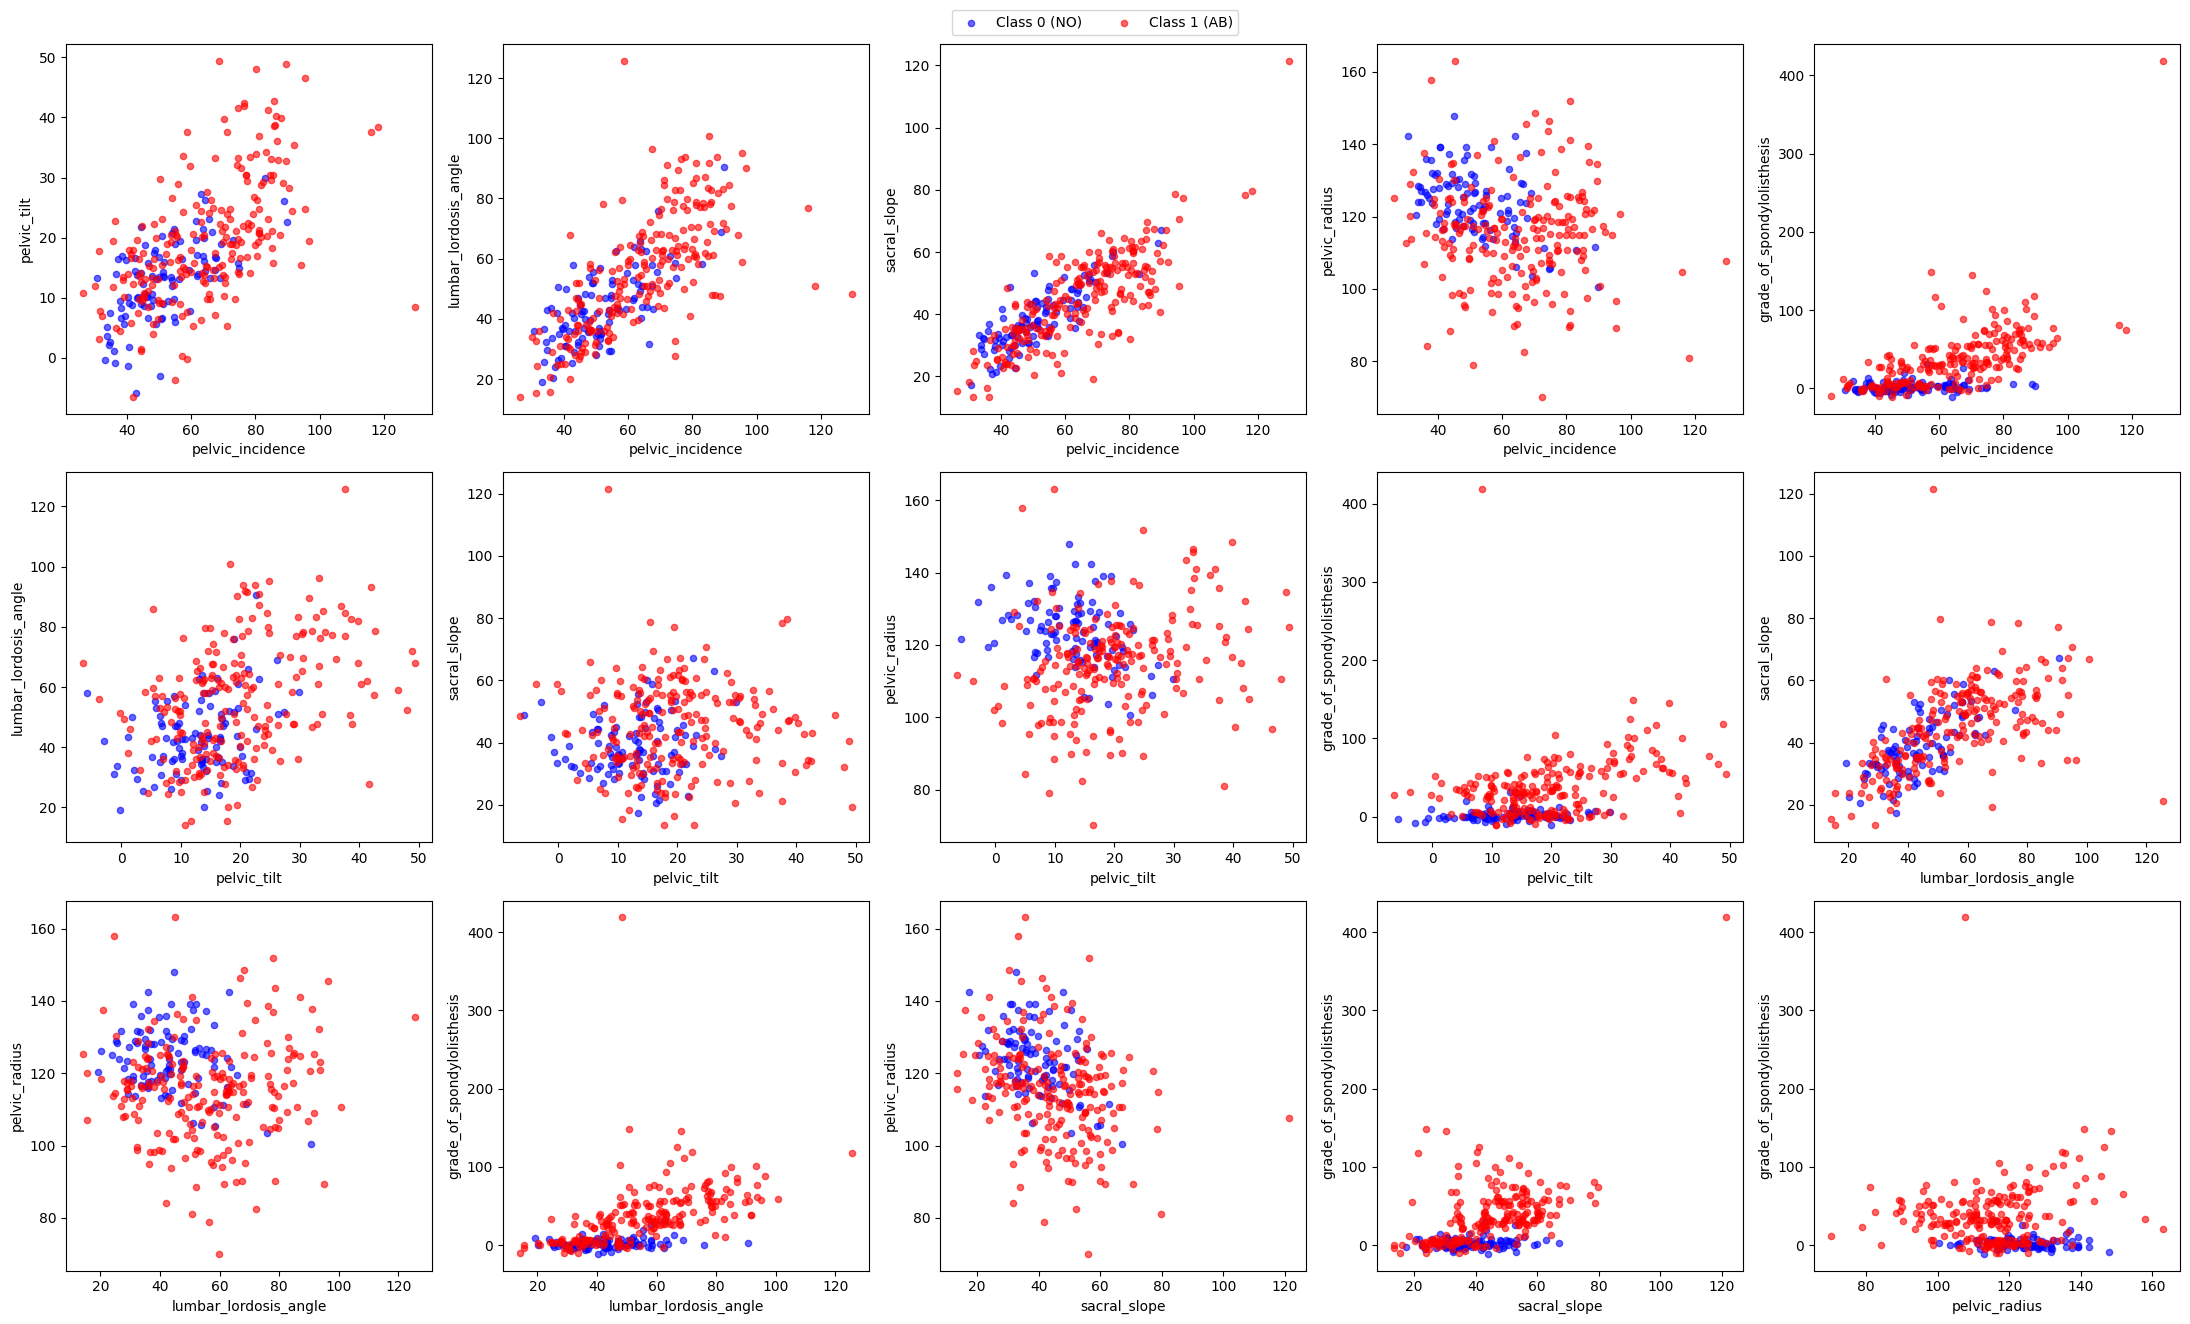

In [39]:
df['class'] = df['class'].map({'NO': 0, 'AB': 1})

import matplotlib.pyplot as plt
from itertools import combinations

feature_columns = [
    "pelvic_incidence",
    "pelvic_tilt",
    "lumbar_lordosis_angle",
    "sacral_slope",
    "pelvic_radius",
    "grade_of_spondylolisthesis"
]

# 六个变量两两组合，共 C(6, 2) = 15 种组合
feature_pairs = list(combinations(feature_columns, 2))

fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()

for ax, (x_variable, y_variable) in zip(axes, feature_pairs):

    class_0 = df[df["class"] == 0]
    class_1 = df[df["class"] == 1]

    ax.scatter(
        class_0[x_variable],
        class_0[y_variable],
        color="blue",
        alpha=0.6,
        s=20,
        label="Class 0 (NO)"
    )

    ax.scatter(
        class_1[x_variable],
        class_1[y_variable],
        color="red",
        alpha=0.6,
        s=20,
        label="Class 1 (AB)"
    )

    ax.set_xlabel(x_variable)
    ax.set_ylabel(y_variable)

# 只显示一个统一图例，避免每张图都有重复图例
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()
plt.show()

#### ii. Boxplots

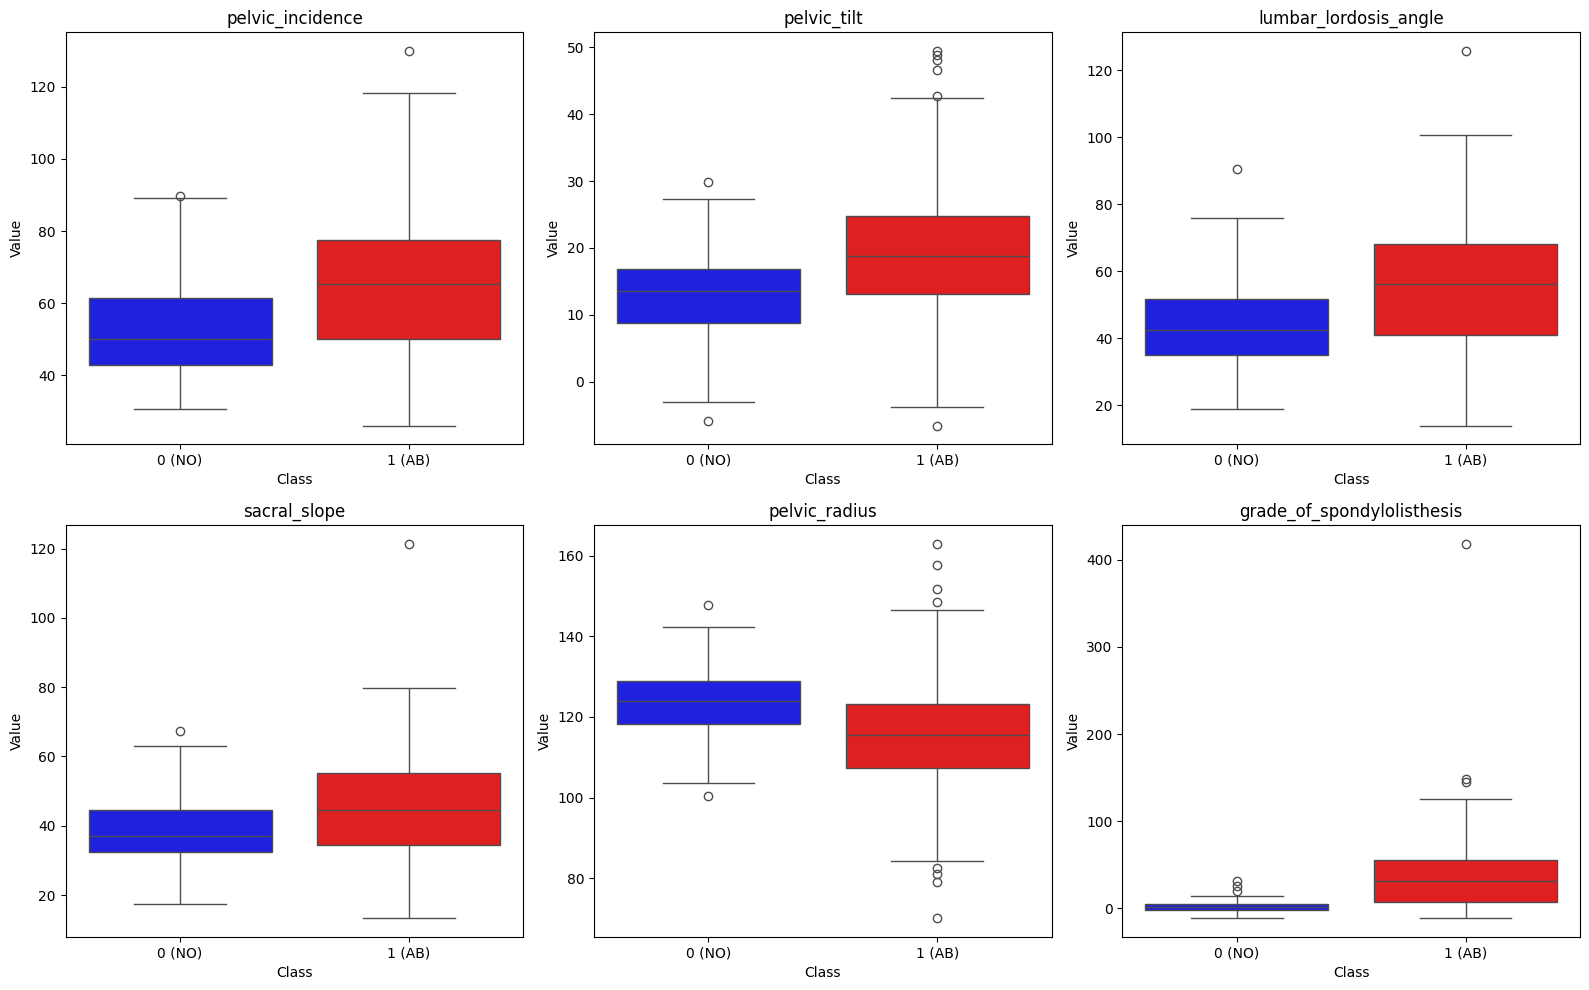

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_columns = [
    "pelvic_incidence",
    "pelvic_tilt",
    "lumbar_lordosis_angle",
    "sacral_slope",
    "pelvic_radius",
    "grade_of_spondylolisthesis"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, feature_columns):
    sns.boxplot(
        data=df,
        x="class",
        y=feature,
        hue="class",
        palette={0: "blue", 1: "red"},
        legend=False,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Class")
    ax.set_ylabel("Value")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0 (NO)", "1 (AB)"])

plt.tight_layout()
plt.show()

#### iii. Split Data Set

In [41]:
# Obtain the row indices required for training and testing
train_indices = (
    df[df["class"] == 0].index[:70].tolist()
    + df[df["class"] == 1].index[:140].tolist()
)

test_indices = (
    df[df["class"] == 0].index[70:].tolist()
    + df[df["class"] == 1].index[140:].tolist()
)

# Split predictors and class labels directly
X_train = df.loc[train_indices, feature_columns]
y_train = df.loc[train_indices, "class"]

X_test = df.loc[test_indices, feature_columns]
y_test = df.loc[test_indices, "class"]

In [42]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

(210, 6) (210,)
(100, 6) (100,)
class
0     70
1    140
Name: count, dtype: int64
class
0    30
1    70
Name: count, dtype: int64


### (c) Classification

#### i. Euclidean Metric

In [43]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=3, # example
    metric="euclidean"
)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### ii. Test Data

In [44]:
k_values = list(range(208, 0, -3))
print(k_values)

[208, 205, 202, 199, 196, 193, 190, 187, 184, 181, 178, 175, 172, 169, 166, 163, 160, 157, 154, 151, 148, 145, 142, 139, 136, 133, 130, 127, 124, 121, 118, 115, 112, 109, 106, 103, 100, 97, 94, 91, 88, 85, 82, 79, 76, 73, 70, 67, 64, 61, 58, 55, 52, 49, 46, 43, 40, 37, 34, 31, 28, 25, 22, 19, 16, 13, 10, 7, 4, 1]


In [45]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = list(range(208, 0, -3))

train_errors = []
test_errors = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    knn.fit(X_train, y_train)

    train_predictions = knn.predict(X_train)
    test_predictions = knn.predict(X_test)

    train_errors.append(
        1 - accuracy_score(y_train, train_predictions)
    )

    test_errors.append(
        1 - accuracy_score(y_test, test_predictions)
    )

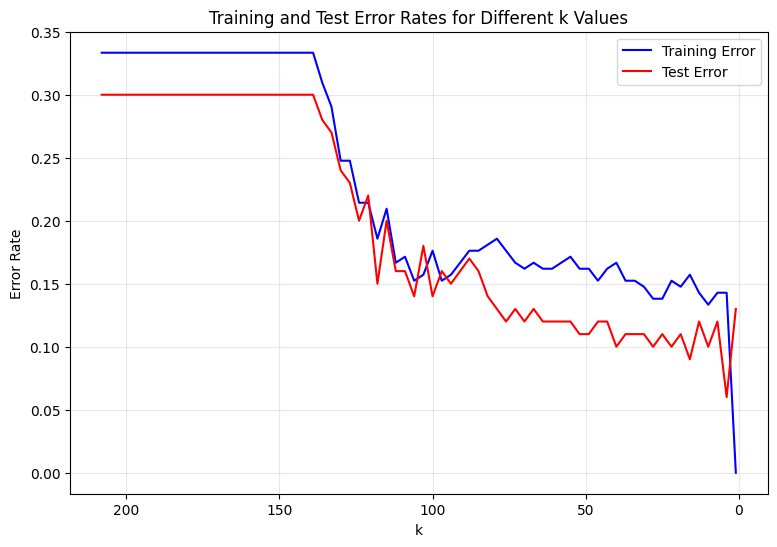

In [46]:
plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    train_errors,
    label="Training Error",
    color="blue"
)

plt.plot(
    k_values,
    test_errors,
    label="Test Error",
    color="red"
)

plt.xlabel("k")
plt.ylabel("Error Rate")
plt.title("Training and Test Error Rates for Different k Values")
plt.legend()
plt.grid(alpha=0.3)

# 让横轴按照题目要求从208递减到1
plt.gca().invert_xaxis()

plt.show()

In [47]:
minimum_test_error = min(test_errors)
best_k = k_values[test_errors.index(minimum_test_error)]

print("Best k:", best_k)
print("Minimum test error:", minimum_test_error)

Best k: 4
Minimum test error: 0.06000000000000005


In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# Fit KNN using the optimal k
best_knn = KNeighborsClassifier(
    n_neighbors=4,
    metric="euclidean"
)

best_knn.fit(X_train, y_train)

# Predict the test set
y_test_pred = best_knn.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[25  5]
 [ 1 69]]


In [49]:
tn, fp, fn, tp = cm.ravel()

true_positive_rate = tp / (tp + fn)
true_negative_rate = tn / (tn + fp)
precision = tp / (tp + fp)
f1_score = 2 * precision * true_positive_rate / (
    precision + true_positive_rate
)

print("True Positive Rate:", true_positive_rate)
print("True Negative Rate:", true_negative_rate)
print("Precision:", precision)
print("F1-score:", f1_score)

True Positive Rate: 0.9857142857142858
True Negative Rate: 0.8333333333333334
Precision: 0.9324324324324325
F1-score: 0.9583333333333333


#### iii. Learning Curve

In [51]:
class_0_train_indices = y_train[y_train == 0].index
class_1_train_indices = y_train[y_train == 1].index

In [52]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

training_sizes = list(range(10, 211, 10))

best_test_errors = []
optimal_k_values = []

for N in training_sizes:

    # Number of observations selected from each class
    n_class_0 = N // 3
    n_class_1 = N - n_class_0

    # Select the first required rows from each class
    subset_indices = (
        class_0_train_indices[:n_class_0].tolist()
        + class_1_train_indices[:n_class_1].tolist()
    )

    X_train_subset = X_train.loc[subset_indices]
    y_train_subset = y_train.loc[subset_indices]

    # Candidate k values: 1, 6, 11, ...
    k_candidates = list(range(1, N, 5))

    test_errors_for_N = []

    for k in k_candidates:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric="euclidean"
        )

        knn.fit(X_train_subset, y_train_subset)

        y_test_pred = knn.predict(X_test)

        test_error = 1 - accuracy_score(
            y_test,
            y_test_pred
        )

        test_errors_for_N.append(test_error)

    # Find the minimum test error and its corresponding k
    best_error = min(test_errors_for_N)
    best_k = k_candidates[
        test_errors_for_N.index(best_error)
    ]

    best_test_errors.append(best_error)
    optimal_k_values.append(best_k)

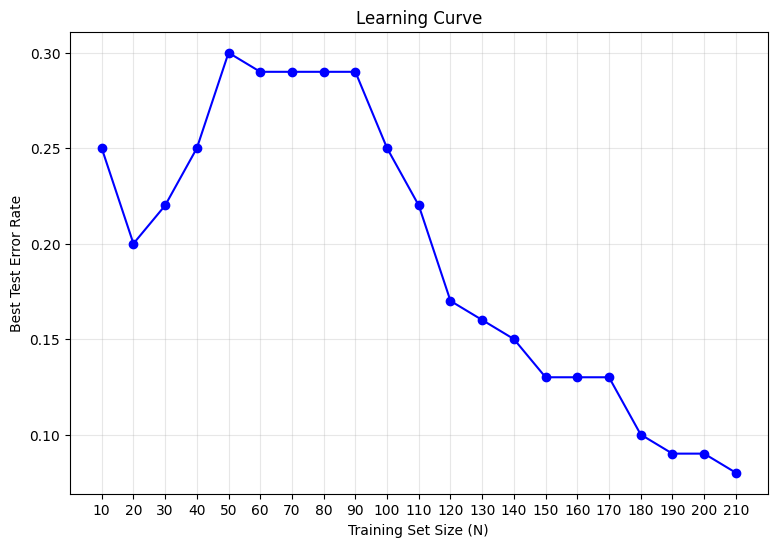

In [53]:
plt.figure(figsize=(9, 6))

plt.plot(
    training_sizes,
    best_test_errors,
    marker="o",
    color="blue"
)

plt.xlabel("Training Set Size (N)")
plt.ylabel("Best Test Error Rate")
plt.title("Learning Curve")
plt.xticks(training_sizes)
plt.grid(alpha=0.3)

plt.show()

### (d) Other Metrics

#### i. Minkowski Distance.

##### A. Manhattan Distance with p = 1.

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = list(range(1, 197, 5))

def find_best_k(metric, metric_params=None):
    test_errors = []

    for k in k_values:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            metric_params=metric_params,
            algorithm="brute"
        )

        knn.fit(X_train, y_train)
        y_test_pred = knn.predict(X_test)

        test_error = 1 - accuracy_score(
            y_test,
            y_test_pred
        )

        test_errors.append(test_error)

    best_error = min(test_errors)
    best_k = k_values[test_errors.index(best_error)]

    return best_k, best_error

In [55]:
manhattan_k, manhattan_error = find_best_k(
    metric="minkowski",
    metric_params={"p": 1}
)

print("Best k for Manhattan:", manhattan_k)
print("Best Manhattan test error:", manhattan_error)

/Users/xiada/keck_venv/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: SyntaxWarning: Parameter p is found in metric_params. The corresponding parameter from __init__ is ignored.
  return self._fit(X, y)
/Users/xiada/keck_venv/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: SyntaxWarning: Parameter p is found in metric_params. The corresponding parameter from __init__ is ignored.
  return self._fit(X, y)
/Users/xiada/keck_venv/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: SyntaxWarning: Parameter p is found in metric_params. The corresponding parameter from __init__ is ignored.
  return self._fit(X, y)
/Users/xiada/keck_venv/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: SyntaxWarning: Parameter p is found in metric_params. The corresponding parameter from __init__ is ignored.
  return self._fit(X, y)
/Users/xiada/keck_venv/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243

Best k for Manhattan: 6
Best Manhattan test error: 0.10999999999999999


/Users/xiada/keck_venv/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: SyntaxWarning: Parameter p is found in metric_params. The corresponding parameter from __init__ is ignored.
  return self._fit(X, y)


##### B. With log10(p) in {0.1, 0.2, 0.3, ... ,1}.

In [56]:
k = manhattan_k

log10_p_values = np.arange(0.1, 1.1, 0.1)

minkowski_errors = []

for log10_p in log10_p_values:
    p = 10 ** log10_p

    knn = KNeighborsClassifier(
        n_neighbors=manhattan_k,
        metric="minkowski",
        p=p,
        algorithm="brute"
    )

    knn.fit(X_train, y_train)
    y_test_pred = knn.predict(X_test)

    test_error = 1 - accuracy_score(
        y_test,
        y_test_pred
    )

    minkowski_errors.append(test_error)

best_minkowski_error = min(minkowski_errors)

best_log10_p = log10_p_values[
    minkowski_errors.index(best_minkowski_error)
]

best_p = 10 ** best_log10_p

print("Fixed k:", manhattan_k)
print("Best log10(p):", round(best_log10_p, 1))
print("Corresponding p:", best_p)
print("Best Minkowski test error:", best_minkowski_error)

Fixed k: 6
Best log10(p): 0.6
Corresponding p: 3.981071705534973
Best Minkowski test error: 0.06000000000000005


##### C. Chebyshev Distance With p -> infinity.

In [58]:
chebyshev_k, chebyshev_error = find_best_k(
    metric="chebyshev"
)

print("Best k for Chebyshev:", chebyshev_k)
print("Best Chebyshev test error:", chebyshev_error)

Best k for Chebyshev: 16
Best Chebyshev test error: 0.07999999999999996


#### ii. Mahalanobis Distance.

In [59]:
covariance_matrix = np.cov(
    X_train,
    rowvar=False
)

inverse_covariance_matrix = np.linalg.inv(
    covariance_matrix
)

In [60]:
mahalanobis_k, mahalanobis_error = find_best_k(
    metric="mahalanobis",
    metric_params={"VI": inverse_covariance_matrix}
)

print("Best k for Mahalanobis:", mahalanobis_k)
print("Best Mahalanobis test error:", mahalanobis_error)

Best k for Mahalanobis: 1
Best Mahalanobis test error: 0.17000000000000004


### (e) Weighted Decision

In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

k_values = list(range(1, 197, 5))

def find_best_weighted_knn(metric):
    test_errors = []

    for k in k_values:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            weights="distance",
            algorithm="brute"
        )

        knn.fit(X_train, y_train)
        y_test_pred = knn.predict(X_test)

        test_error = 1 - accuracy_score(
            y_test,
            y_test_pred
        )

        test_errors.append(test_error)

    best_error = min(test_errors)
    best_k = k_values[test_errors.index(best_error)]

    return best_k, best_error

In [63]:
euclidean_k, euclidean_error = find_best_weighted_knn(
    metric="euclidean"
)

manhattan_k_weighted, manhattan_error_weighted = (
    find_best_weighted_knn(metric="manhattan")
)

chebyshev_k_weighted, chebyshev_error_weighted = (
    find_best_weighted_knn(metric="chebyshev")
)

weighted_results = pd.DataFrame({
    "Distance Metric": [
        "Euclidean",
        "Manhattan",
        "Chebyshev"
    ],
    "Optimal k": [
        euclidean_k,
        manhattan_k_weighted,
        chebyshev_k_weighted
    ],
    "Best Test Error": [
        euclidean_error,
        manhattan_error_weighted,
        chebyshev_error_weighted
    ]
})

weighted_results

,Distance Metric,Optimal k,Best Test Error
0,Euclidean,6,0.10
1,Manhattan,26,0.10
2,Chebyshev,16,0.11


### (f) Training Error Rate

The lowest training error rate achieved in this homework was 0, obtained using KNN with \(k=1\). When the KNN model predicts the training data, each training observation is its own nearest neighbor with a distance of zero, so it is assigned its original class label. Therefore, 1-NN effectively memorizes the training data and achieves zero training error. 

However, it can be sensitive to noise and may overfit, so the lowest training error does not necessarily indicate the best generalization performance on unseen data.